<h1 style="color:rgb(242, 176, 235); font-size:32px;">Import modules</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Loading datasets</h1>

In [2]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimYear": perf.get("SwimYear"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

   points       mpp    mpp_date  SwimTime SwimYear SwimTimeSeconds Status  \
0   930.0  02:08.48  2025-1

In [22]:
print("Les annees disponibles sont ", df["SwimYear"].unique())

Les annees disponibles sont  [None]


In [25]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

unique_years = df['SwimDate'].dt.year.dropna().unique()

unique_years_list = sorted(int(year) for year in unique_years)

print("Les années uniques sont :", unique_years_list)

Les années uniques sont : [1976, 1980, 1984, 1987, 1988, 1990, 1991, 1992, 1994, 1996, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [18]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimYear', 'SwimTimeSeconds', 'Status',
       'Speed', 'swimmer', 'splits'],
      dtype='object')


In [4]:
print("Nombre de lignes :", df.shape[0])  # 762371

Nombre de lignes : 762371


In [5]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [36]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Age': 12,
  'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 12,
  'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [37]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [38]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.4837,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 2.6525,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 4.6802,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 7.0004,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


In [3]:
import unicodedata

df_check = df.explode("swimmer").copy()
df_check = df_check[df_check["swimmer"].apply(lambda x: isinstance(x, dict))]

df_check["Nageur"] = df_check["swimmer"].apply(lambda x: x.get("Name"))
df_check["Sexe"] = df_check["swimmer"].apply(lambda x: x.get("Gender"))
df_check["Annee"] = df_check["swimmer"].apply(lambda x: x.get("Year_of_birth"))

def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = " ".join(x.split()) 
    x = unicodedata.normalize("NFC", x)
    return x

def normalize_sex(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    return x

df_check["Nageur_clean"] = df_check["Nageur"].map(normalize_text)
df_check["Sexe_clean"] = df_check["Sexe"].map(normalize_sex)
df_check["Annee_clean"] = pd.to_numeric(df_check["Annee"], errors="coerce").astype("Int64")

CURRENT_YEAR = pd.Timestamp.today().year

issues = {
    "annee_manquante": df_check[df_check["Annee_clean"].isna()],
    "annee_hors_plage": df_check[
        df_check["Annee_clean"].notna() &
        ((df_check["Annee_clean"] < 1900) | (df_check["Annee_clean"] > CURRENT_YEAR))
    ],
    "nageur_manquant": df_check[df_check["Nageur_clean"].isna() | (df_check["Nageur_clean"] == "")],
    "sexe_invalide": df_check[~df_check["Sexe_clean"].isin(["M", "F"]) & df_check["Sexe_clean"].notna()],
    "sexe_manquant": df_check[df_check["Sexe_clean"].isna()],
}

print(" Résumé qualité Année / Nageur / Sexe ")
for k, v in issues.items():
    print(f"{k:20s}: {len(v)}")

consistency = (
    df_check.dropna(subset=["Nageur_clean"])
    .groupby("Nageur_clean", as_index=False)
    .agg(nb_sexes=("Sexe_clean", "nunique"),
         nb_annees=("Annee_clean", "nunique"))
)

incoherent = consistency[(consistency["nb_sexes"] > 1) | (consistency["nb_annees"] > 1)]
print(f"\nNageurs incohérents (plusieurs sexes/années): {len(incoherent)}")

print("\n Exemples annee_hors_plage ")
display(issues["annee_hors_plage"][["Nageur", "Annee", "Sexe"]].head(10))

print("\n Exemples sexe_invalide ")
display(issues["sexe_invalide"][["Nageur", "Annee", "Sexe"]].head(10))

print("\n Exemples nageurs incohérents ")
display(incoherent.head(20))

 Résumé qualité Année / Nageur / Sexe 
annee_manquante     : 0
annee_hors_plage    : 4
nageur_manquant     : 0
sexe_invalide       : 0
sexe_manquant       : 0

Nageurs incohérents (plusieurs sexes/années): 314

 Exemples annee_hors_plage 


,Nageur,Annee,Sexe
73249,Paut Karlo-Noah,4200,M
73322,Paut Karlo-Noah,4200,M
73896,Paut Karlo-Noah,4200,M
74144,Paut Karlo-Noah,4200,M



 Exemples sexe_invalide 


,Nageur,Annee,Sexe



 Exemples nageurs incohérents 


,Nageur_clean,nb_sexes,nb_annees
949,Alarcon Elise,1,2
1338,Allard Nicolas,1,2
1951,Andrieu Gabriel,1,2
2034,Angot Julien,1,2
2120,Antoine Pauline,1,2
2408,Armand Agathe,1,2
2888,Aubry Jonathan,1,2
3966,Barbier Antoine,1,2
4117,Barillet Lucie,1,2
4175,Baron Mathilde,1,2


<h1 style="color:#F0B4B4; font-size:32px;">Histogram of swim times</h1>

Nombre de performances pour l'event 100 FR LCM: 49724


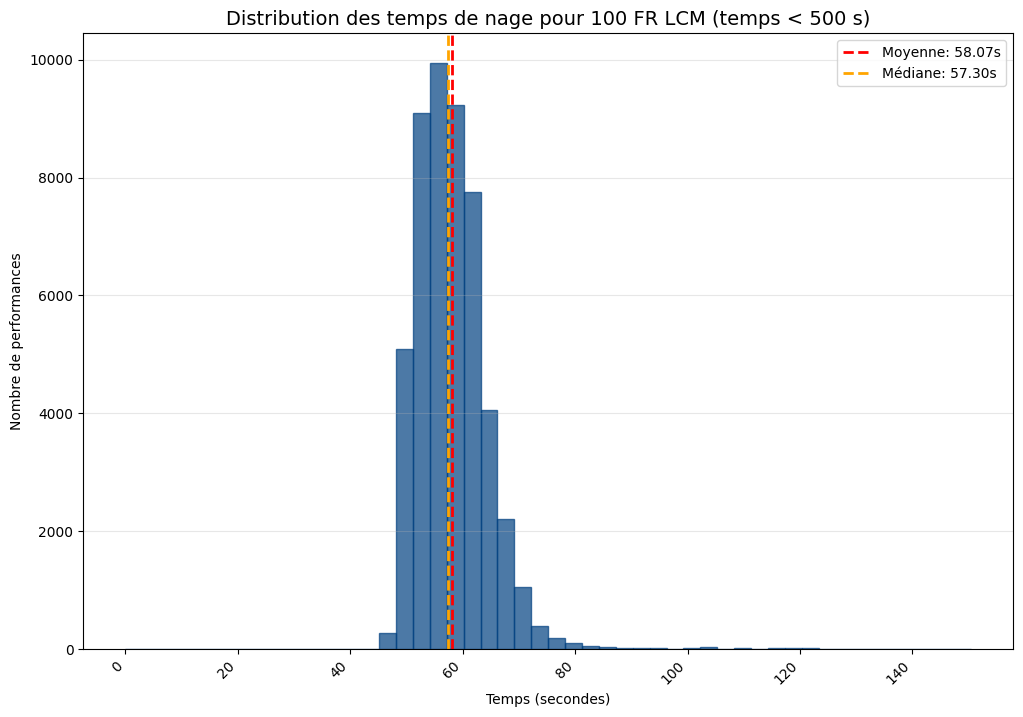

In [39]:
from matplotlib.ticker import MaxNLocator

nom_event = "100 FR LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
].dropna()

print(f"Nombre de performances pour l'event {nom_event}: {len(swim_times)}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
           label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2,
           label=f'Médiane: {median_time:.2f}s')

ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Histogram with Kernel Density Estimate (KDE)</h1>

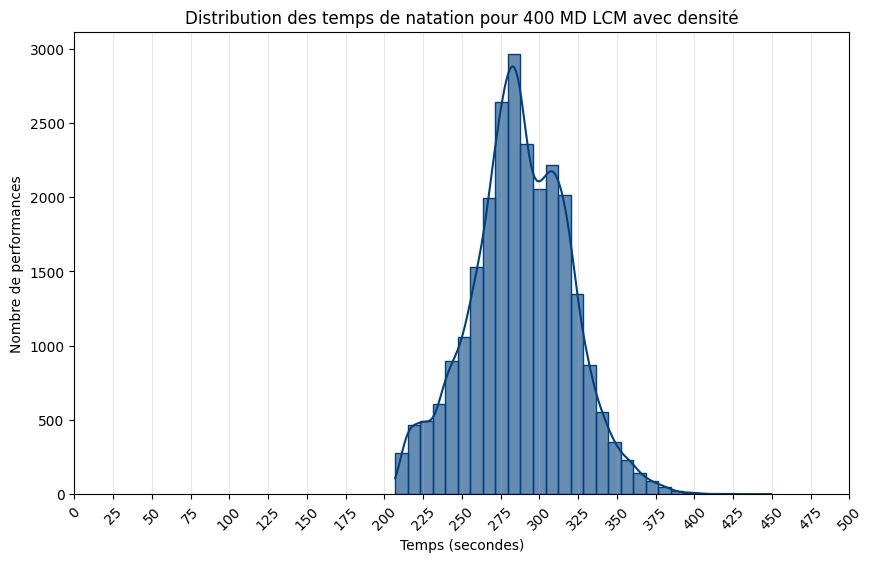

In [10]:
nom_event = "400 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"].notna()) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

plt.figure(figsize=(10,6))

sns.histplot(
    swim_times,
    bins=30,
    kde=True,
    color="#004080",
    edgecolor="#004080",
    alpha=0.6
)

plt.title(f"Distribution des temps de natation pour {nom_event} avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Cumulative Histogram</h1>

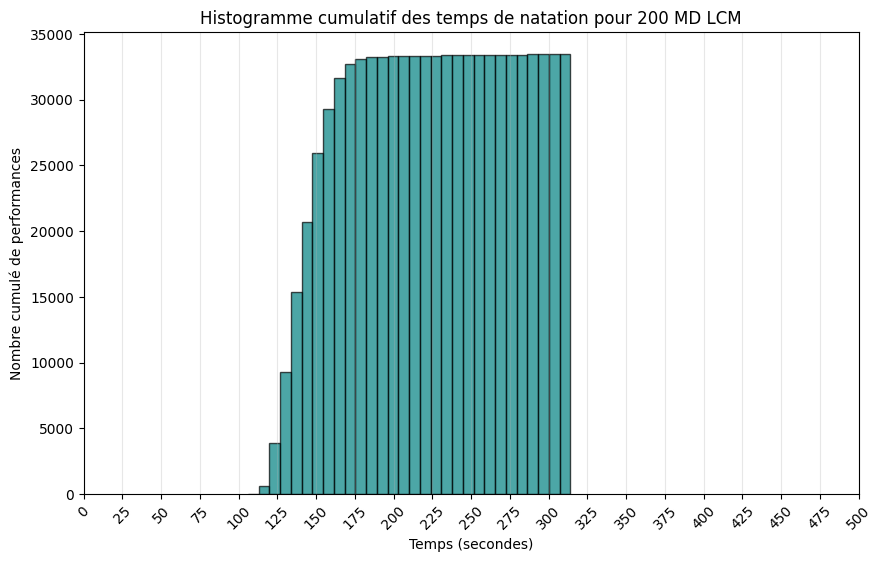

In [11]:
nom_event = "200 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

if len(swim_times) > 0:
    plt.figure(figsize=(10,6))

    plt.hist(
        swim_times,
        bins=30,
        cumulative=True,
        color="#008080",
        edgecolor="black",
        alpha=0.7
    )

    plt.title(f"Histogramme cumulatif des temps de natation pour {nom_event}")
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Nombre cumulé de performances")

    plt.xticks(np.arange(0, 501, 25), rotation=45)
    plt.grid(axis="x", alpha=0.3)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

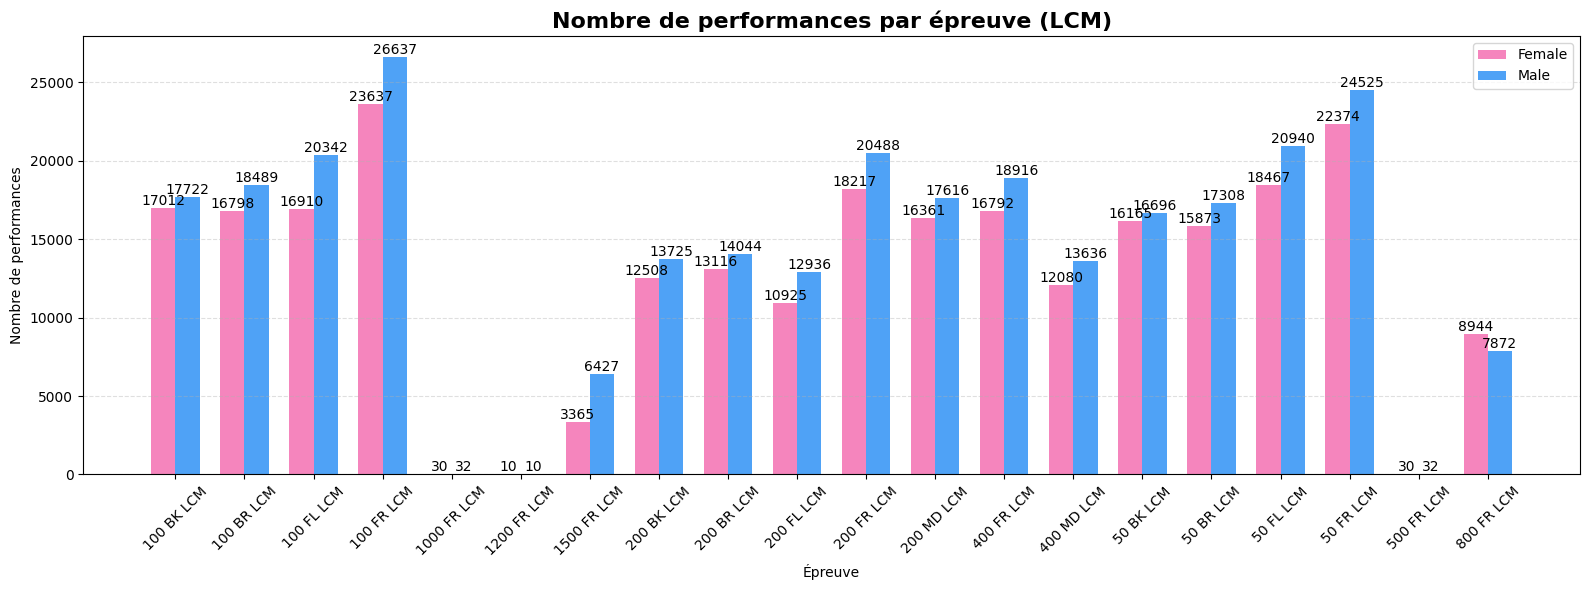

In [13]:
course_type = "LCM"

df["Gender"] = df["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 else None
)

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 else None
)

df_clean = df.dropna(subset=["Gender", "Event", "swimmer_name"])

df_clean = df_clean[df_clean["Event"].str.contains(course_type, na=False)]

df_counts = (
    df_clean
    .groupby(["Event", "Gender"])["swimmer_name"]
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

events = df_counts.index

female_counts = df_counts["F"] if "F" in df_counts else pd.Series(0, index=events)
male_counts = df_counts["M"] if "M" in df_counts else pd.Series(0, index=events)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16, 6))

bars1 = plt.bar(
    x - width/2, female_counts, width,
    label="Female", color="#F585BD"
)

bars2 = plt.bar(
    x + width/2, male_counts, width,
    label="Male", color="#4FA2F6"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title(
    f"Nombre de performances par épreuve ({course_type})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Épreuve")
plt.ylabel("Nombre de performances")

plt.xticks(x, events, rotation=45)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

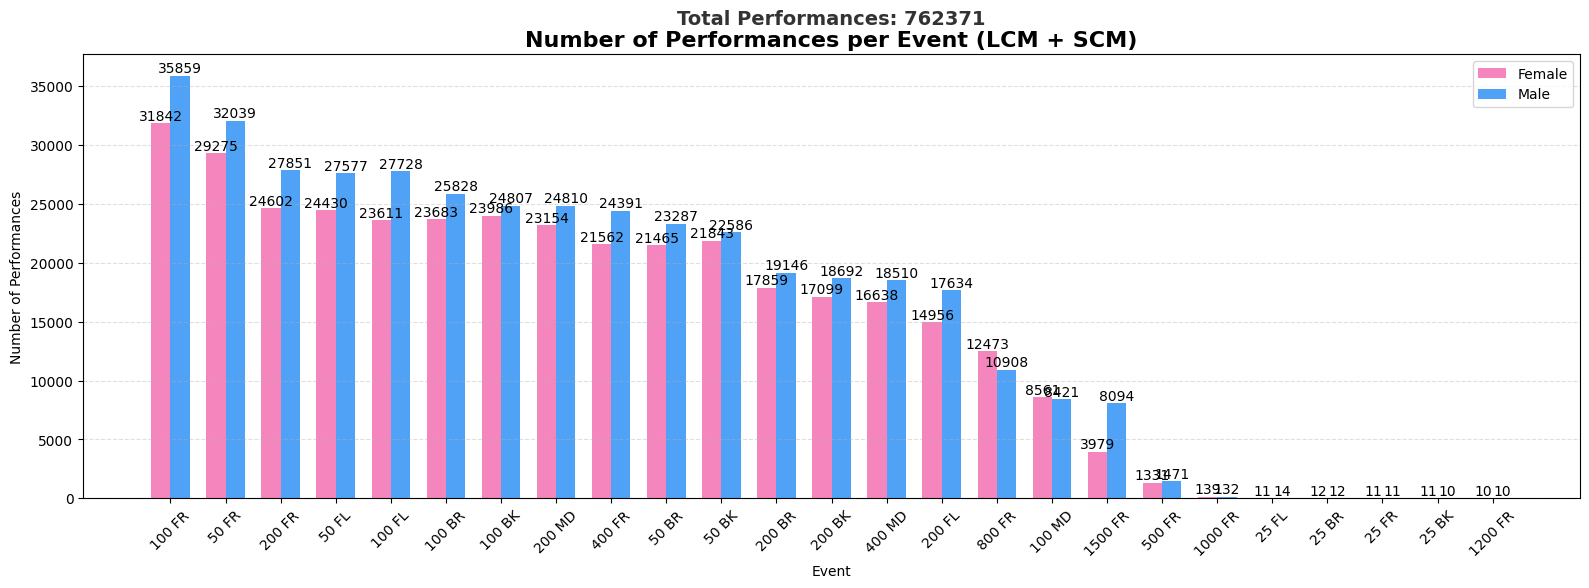

In [ ]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["Event_clean"] = df["Event"].str.replace(" LCM", "", regex=False)\
                               .str.replace(" SCM", "", regex=False)

df_clean = df.dropna(subset=["Gender", "Event_clean"])

df_counts = (
    df_clean
    .groupby(["Event_clean", "Gender"])
    .size()
    .unstack(fill_value=0)
)

df_counts["Total"] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values("Total", ascending=False).drop(columns="Total")

total_performances = df_counts.sum().sum()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Performances per Event (LCM + SCM)", fontsize=16, fontweight="bold")

plt.text(
    0.5, 1.08,
    f"Total Performances: {int(total_performances)}",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight='bold',
    color="#333333"
)

plt.xlabel("Event")
plt.ylabel("Number of Performances")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Countplot total number of performances by sex</h1>

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


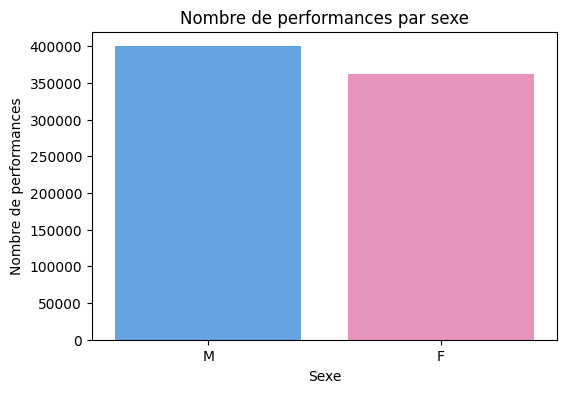

In [14]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

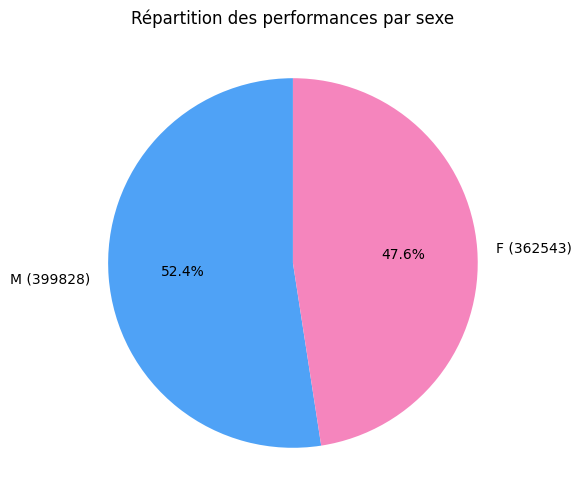

In [31]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

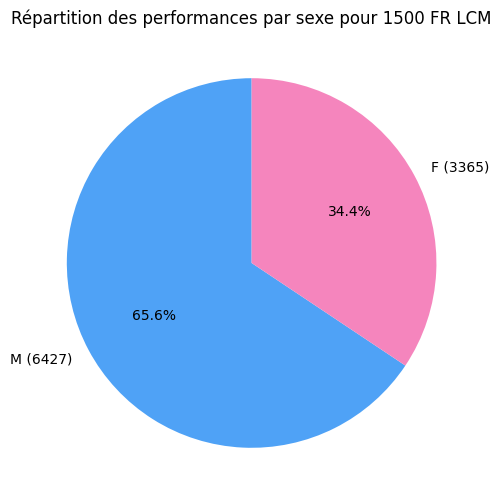

In [33]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

gender_counts = df_event["Gender"].value_counts()

if len(gender_counts) > 0:
    colors = ["#4FA2F6", "#F585BD"]

    plt.figure(figsize=(6,6))

    plt.pie(
        gender_counts,
        labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )

    plt.title(f"Répartition des performances par sexe pour {nom_event}")
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [34]:
print(df['Stroke'].unique()) # ['FR', 'BK', 'BR', 'FL', 'MD']

['FR' 'BK' 'BR' 'FL' 'MD']


<h1 style="color:#F0B4B4; font-size:32px;">Barplot (Diagramme a barres) du temps moyen par stroke et la distance</h1>

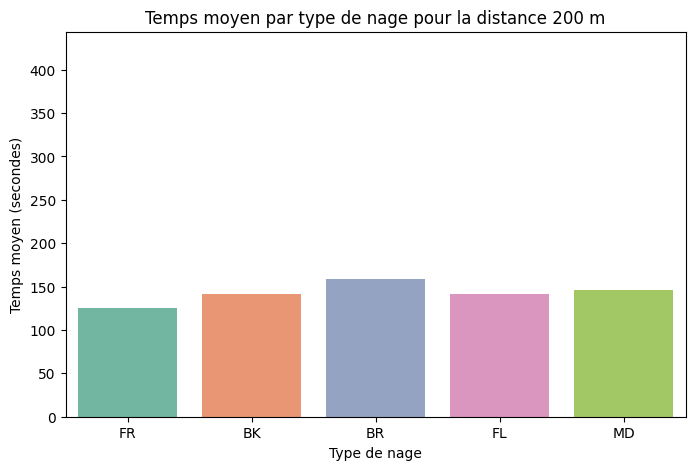

In [35]:
distance_choisie = 200

subset = df[
    (df['SwimTimeSeconds'].notna()) &
    (df['Distance'] == distance_choisie)
]

if len(subset) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Stroke',
        y='SwimTimeSeconds',
        data=subset,
        hue='Stroke',
        palette="Set2",
        errorbar=None,
        dodge=False
    )

    plt.title(f"Temps moyen par type de nage pour la distance {distance_choisie} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps moyen (secondes)")
    plt.ylim(0, subset['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:#F0B4B4; font-size:32px;">Bar Chart: Number of Performances per Club</h1>

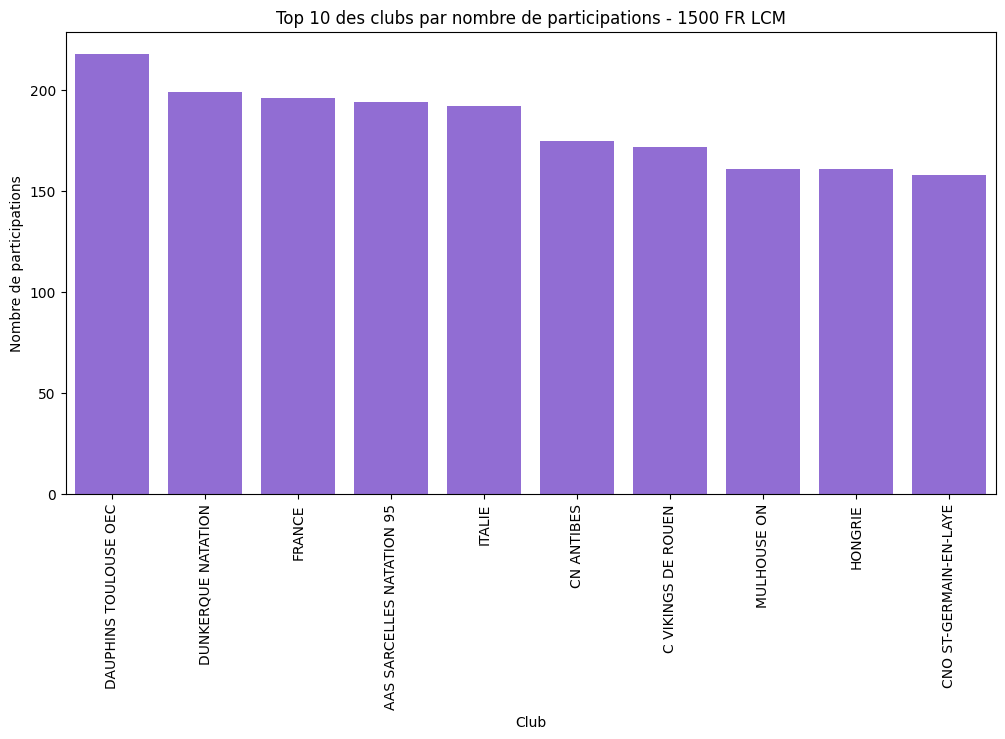

In [36]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event]

top_clubs = df_event["Club"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")

plt.title(f"Top 10 des clubs par nombre de participations - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=90)

plt.show()

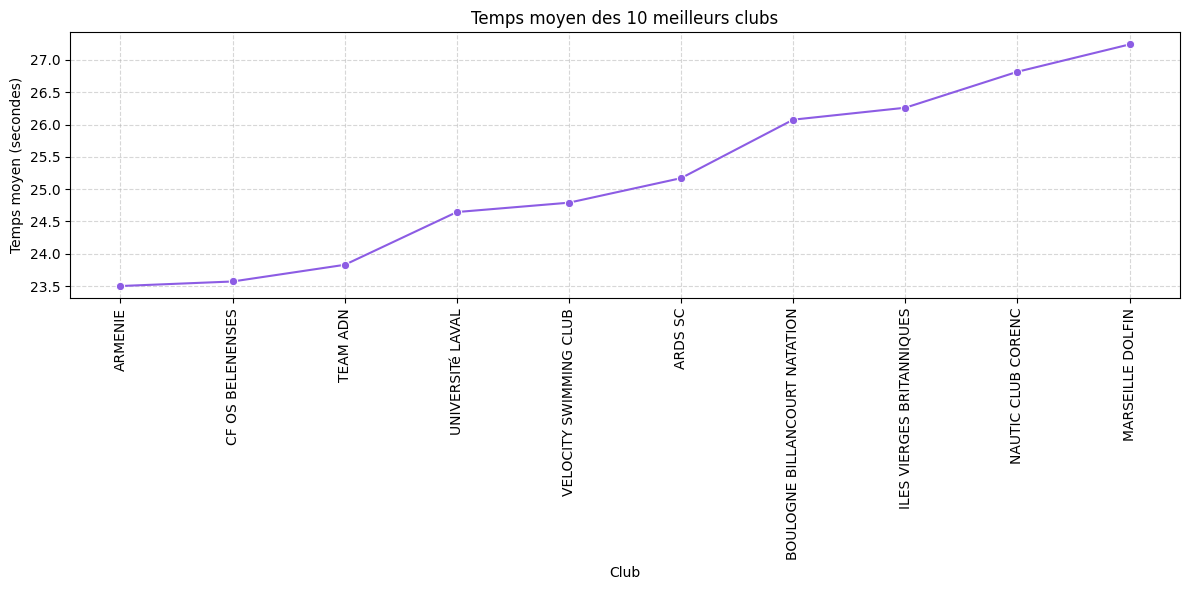

In [21]:
df_time = df[df['SwimTimeSeconds'].notna()]

mean_time_club = df_time.groupby('Club')['SwimTimeSeconds'].mean().reset_index()

mean_time_club = mean_time_club.sort_values('SwimTimeSeconds')

top10_clubs = mean_time_club.head(10)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top10_clubs,
    x='Club',
    y='SwimTimeSeconds',
    marker='o',
    color="#8C5CE4"
)

plt.title("Temps moyen des 10 meilleurs clubs")
plt.xlabel("Club")
plt.ylabel("Temps moyen (secondes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h1>

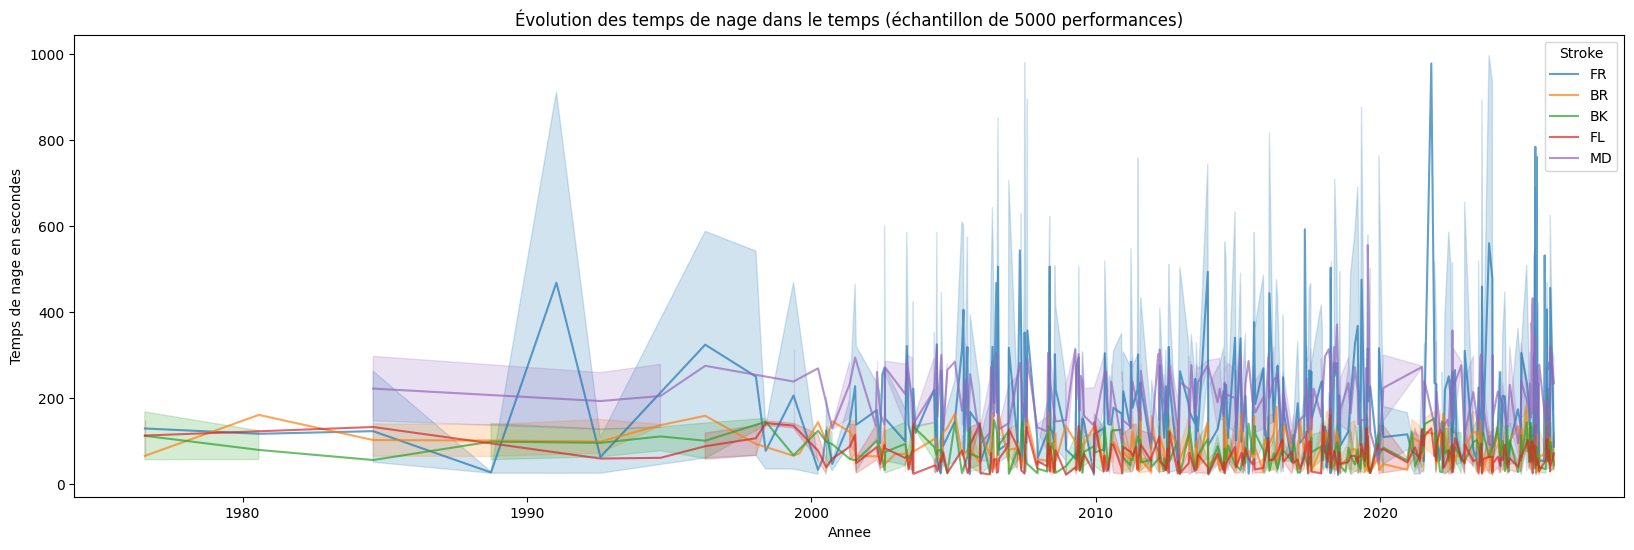

In [39]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'])
plt.figure(figsize=(20,6))
sns.lineplot(x='SwimDate', y='SwimTimeSeconds', data=df.sample(5000), hue='Stroke', alpha=0.7)
plt.title("Évolution des temps de nage dans le temps (échantillon de 5000 performances)")
plt.xlabel("Annee")
plt.ylabel("Temps de nage en secondes")
plt.legend(title='Stroke')
plt.show()

In [40]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

df['Year'] = df['SwimDate'].dt.year

min_year = df['Year'].min()

print("L'année la plus ancienne est :", min_year)

L'année la plus ancienne est : 1976


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/1076660305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


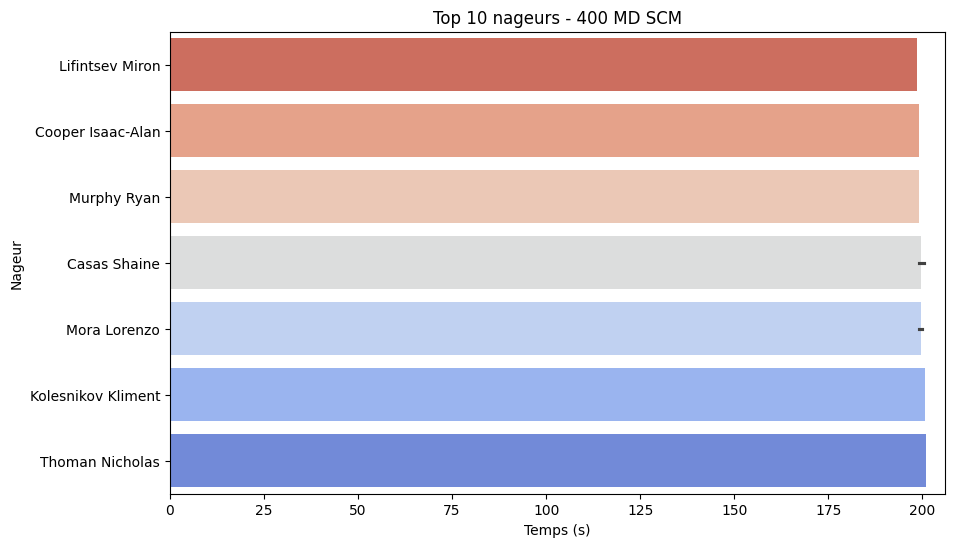

In [51]:
nom_event = "400 MD SCM"

subset = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['SwimTimeSeconds'] > 0)
].copy()

if len(subset) > 0:
    subset['SwimmerName'] = subset['swimmer'].apply(
        lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else "Unknown"
    )

    top10 = subset.nsmallest(10, 'SwimTimeSeconds')

    plt.figure(figsize=(10,6))
    sns.barplot(
        x='SwimTimeSeconds',
        y='SwimmerName',
        data=top10,
        palette="coolwarm_r",
        orient='h'
    )

    plt.title(f"Top 10 nageurs - {nom_event}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Nageur")
    plt.xlim(0, top10['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [49]:
print(df["Distance"].sort_values(ascending=True).unique()) # [  25   50  100  200  400  500  800 1000 1200 1500]

[  25   50  100  200  400  500  800 1000 1200 1500]


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed Performance Across Distances by Stroke</h1>

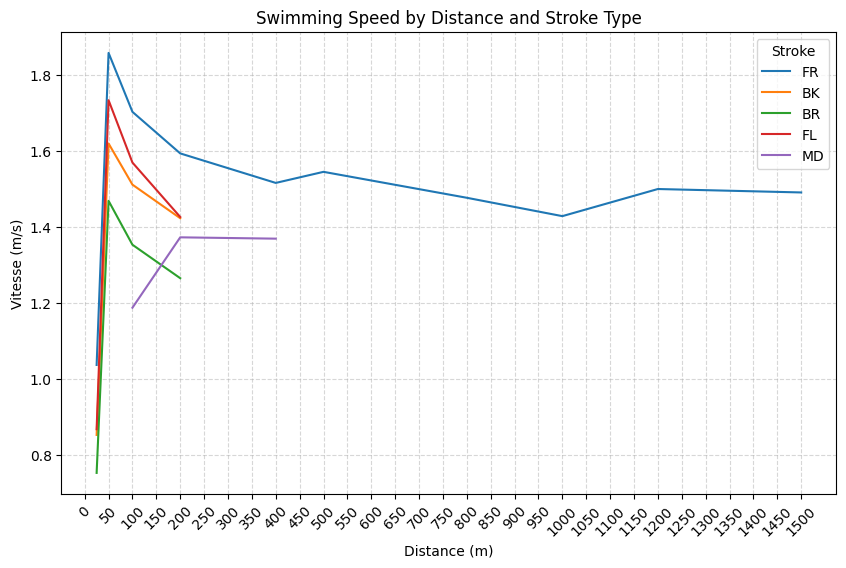

In [55]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


Max speed per distance for stroke: BK


,Swimmer,Distance,Speed
0,Chaberty-Baron Marilou,25,1.2658
1,Manaudou Florent,50,2.2502
2,Murphy Ryan,100,2.0619
3,Kos Hubert,200,1.8930



Max speed per distance for stroke: BR


,Swimmer,Distance,Speed
4,Chaberty-Baron Marilou,25,1.2101
5,Fink Nic,50,1.9701
6,Qin Haiyang,100,1.8028
7,Prigoda Kirill,200,1.6644



Max speed per distance for stroke: FL


,Swimmer,Distance,Speed
8,Chaberty-Baron Marilou,25,1.4837
9,Ponti Non,50,2.3452
10,Ponti Non,100,2.0960
11,Kharun Ilya,200,1.8477



Max speed per distance for stroke: FR


,Swimmer,Distance,Speed
12,Chaberty-Baron Marilou,25,1.6415
13,Crooks Jordan,50,2.5126
14,Leveaux Amaury,100,2.2252
15,Bernard Alain,200,2.4762
16,Alexy Jack,400,2.2019
17,Secchi Clement,500,2.2347
18,Hobson Luke,800,1.9975
19,Cristofini Sauveur,1000,1.6421
20,Chausson Stanislas,1200,1.6113
21,Wellbrock Florian,1500,1.7712



Max speed per distance for stroke: MD


,Swimmer,Distance,Speed
22,Ponti Non,100,1.9869
23,Mora Lorenzo,200,2.2292
24,Lifintsev Miron,400,2.0133


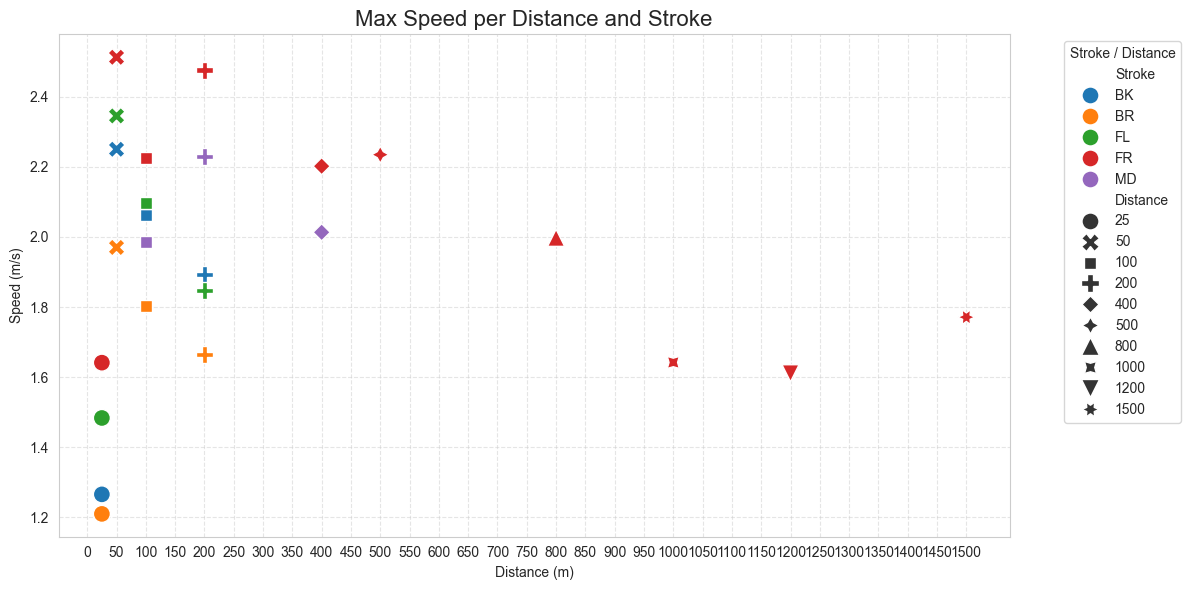

In [78]:
import mplcursors

df_clean = df.loc[df['Speed'].notna(), ['Stroke', 'Distance', 'Speed', 'swimmer']].copy()


def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name')
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict):
        return x[0].get('Name')
    return None

df_clean['Swimmer'] = df_clean['swimmer'].map(clean_swimmer)
df_clean = df_clean.dropna(subset=['Swimmer'])

df_max = df_clean.loc[
    df_clean.groupby(['Stroke', 'Distance'])['Speed'].idxmax()
].reset_index(drop=True)

for stroke in df_max['Stroke'].unique():
    print(f"\nMax speed per distance for stroke: {stroke}")
    display(df_max[df_max['Stroke'] == stroke][['Swimmer','Distance','Speed']])


plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_max,
    x='Distance',
    y='Speed',
    hue='Stroke',      
    style='Distance',   
    s = 150
)

max_distance = int(df_max['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50))

points = df_max[['Distance', 'Speed', 'Swimmer', 'Stroke']].values

cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target

    distances = (points[:,0] - x)**2 + (points[:,1] - y)**2
    idx = distances.argmin()

    sel.annotation.set_text(
        f"{points[idx][2]}\n"
        f"Stroke: {points[idx][3]}\n"
        f"Speed: {points[idx][1]:.2f} m/s\n"
        f"Distance: {int(points[idx][0])} m"
    )

plt.title("Max Speed per Distance and Stroke", fontsize=16)
plt.xlabel("Distance (m)")
plt.ylabel("Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title="Stroke / Distance", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Max Speed per Split Distance and Stroke:


,Swimmer,Stroke,SplitDistance,SplitSpeed
0,Baroni Clement,BK,50,2.784
1,Olivié Nicolas,BK,100,3.228
2,Arhab Botko Mathilde,BK,150,2.266
3,Adjesson Aaliyah,BK,200,2.323
4,Tateishi Ryo,BR,50,2.160
5,Jacquot Raphael,BR,100,3.008
6,Gyurta Daniel,BR,150,1.620
7,Banchereau Léana,BR,200,3.623
8,Ienny Marianne,FL,50,2.950
9,Poirier Lenaïg,FL,100,4.713


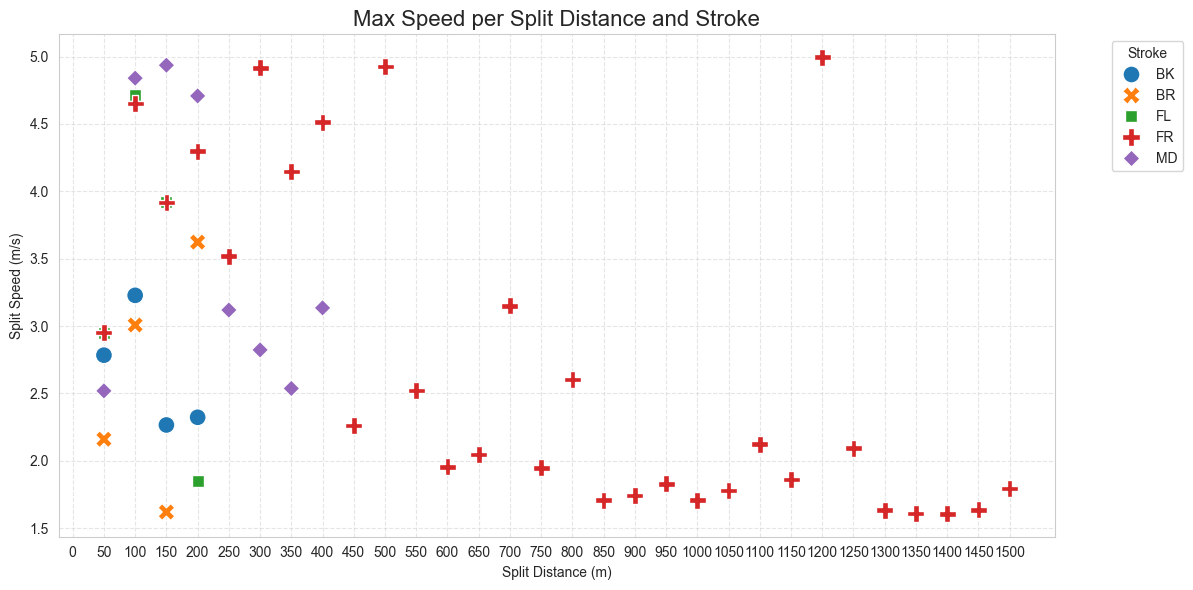

In [7]:
import mplcursors
df_clean = df.loc[df['Speed'].notna(), ['Stroke', 'Distance', 'Speed', 'swimmer', 'splits']].copy()

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name')
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict):
        return x[0].get('Name')
    return None

df_clean['Swimmer'] = df_clean['swimmer'].map(clean_swimmer)
df_clean = df_clean.dropna(subset=['Swimmer'])

df_split = []

for _, row in df_clean.loc[df_clean['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)].iterrows():
    swimmer_name = row['Swimmer']
    stroke = row['Stroke']
    
    for s in row['splits']:
        split_distance = s.get('split_distance')
        split_speed = s.get('split_speed')
        
        if split_distance is not None and split_speed is not None:
            try:
                dist = int(str(split_distance).replace(' m', ''))
                speed = float(split_speed)
                if 0 < speed < 5:
                    df_split.append({
                        'Stroke': stroke,
                        'SplitDistance': dist,
                        'SplitSpeed': speed,
                        'Swimmer': swimmer_name
                    })
            except:
                continue

df_splits = pd.DataFrame(df_split)

df_splits_max = df_splits.loc[
    df_splits.groupby(['Stroke', 'SplitDistance'])['SplitSpeed'].idxmax()
].reset_index(drop=True)

print("Max Speed per Split Distance and Stroke:")
display(df_splits_max[['Swimmer', 'Stroke', 'SplitDistance', 'SplitSpeed']])

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_splits_max,
    x='SplitDistance',
    y='SplitSpeed',
    hue='Stroke',
    style='Stroke',
    s=150
)

max_split = int(df_splits_max['SplitDistance'].max())
plt.xticks(np.arange(0, max_split + 50, 50))

points = df_splits_max[['SplitDistance', 'SplitSpeed', 'Swimmer', 'Stroke']].values

cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    distances = (points[:, 0] - x)**2 + (points[:, 1] - y)**2
    idx = distances.argmin()
    
    sel.annotation.set_text(
        f"{points[idx][2]}\n"
        f"Stroke: {points[idx][3]}\n"
        f"Split Distance: {int(points[idx][0])} m\n"
        f"Split Speed: {points[idx][1]:.2f} m/s"
    )

plt.title("Max Speed per Split Distance and Stroke", fontsize=16)
plt.xlabel("Split Distance (m)")
plt.ylabel("Split Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Stroke", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Heatmap of Average Swim Speed by Distance and Stroke</h1>

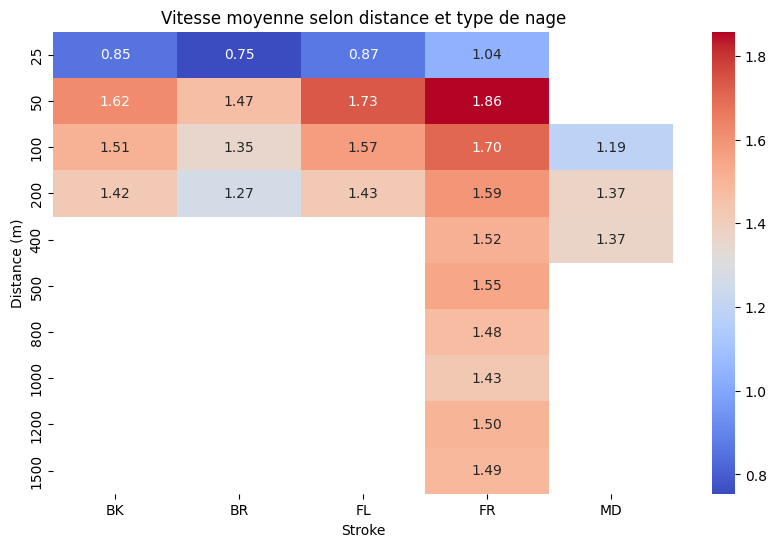

In [5]:
pivot = df.pivot_table(
    values='Speed',
    index='Distance',
    columns='Stroke',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Vitesse moyenne selon distance et type de nage")
plt.xlabel("Stroke")
plt.ylabel("Distance (m)")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h1>

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_38361/1800823130.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


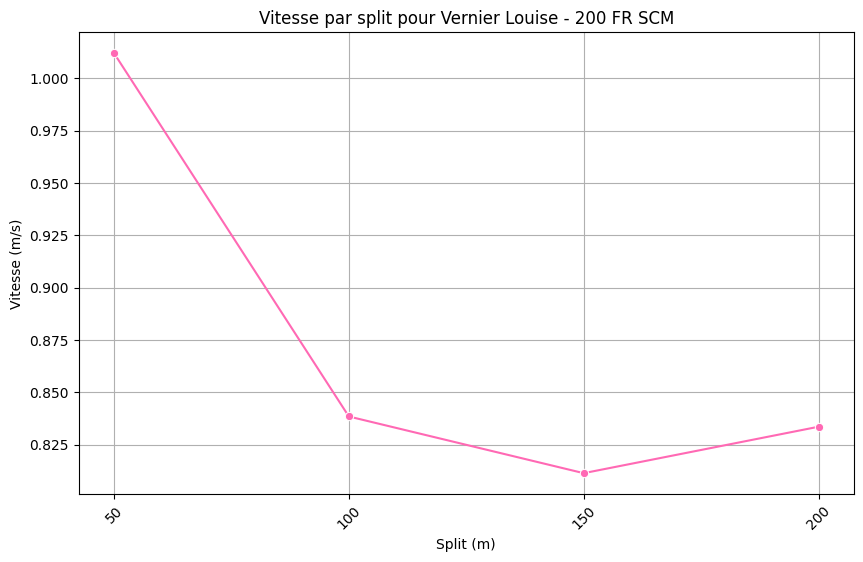

In [15]:
nom_nageur = "Vernier Louise"
nom_event = "200 FR SCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer.get('Gender')  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line,
    ci=None  
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50), rotation=45) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event</h1>

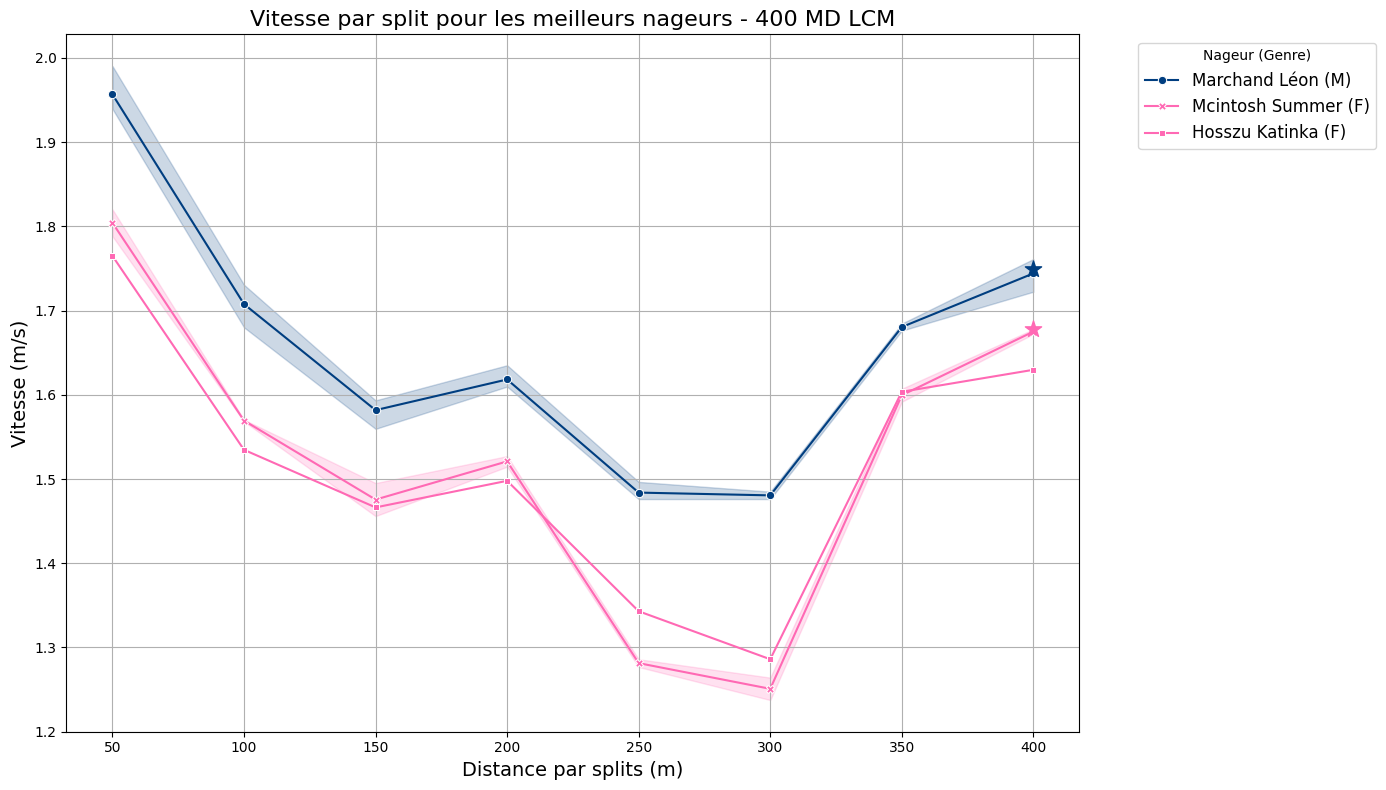

In [49]:
nom_event = "400 MD LCM"
top_n = 3  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    best_male = df_top_men.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]
    best_female = df_top_women.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]

    for swimmer in [best_male, best_female]:
        swimmer_data = df_splits[df_splits['swimmer'] == swimmer]
        color = palette_for_plot[swimmer + f" ({swimmer_data['gender'].iloc[0]})"]

        plt.scatter(
            swimmer_data['split_distance'].iloc[-1],
            swimmer_data['split_speed'].iloc[-1],
            s=150,  
            color=color,
            marker='*',
            zorder=5
        )

    plt.tight_layout()
    plt.show()

In [31]:
df_event = df[
    (df['Event'] == "1500 FR LCM") &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1) &
     df['splits'].apply(lambda x: isinstance(x, list) and len(x) == 15))
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

swimmers_in_event = df_event[['swimmer_name', 'swimmer_gender']].drop_duplicates()

print(len(swimmers_in_event))
# y a des nageurs qui n ont pas tous les splits

947


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h1>

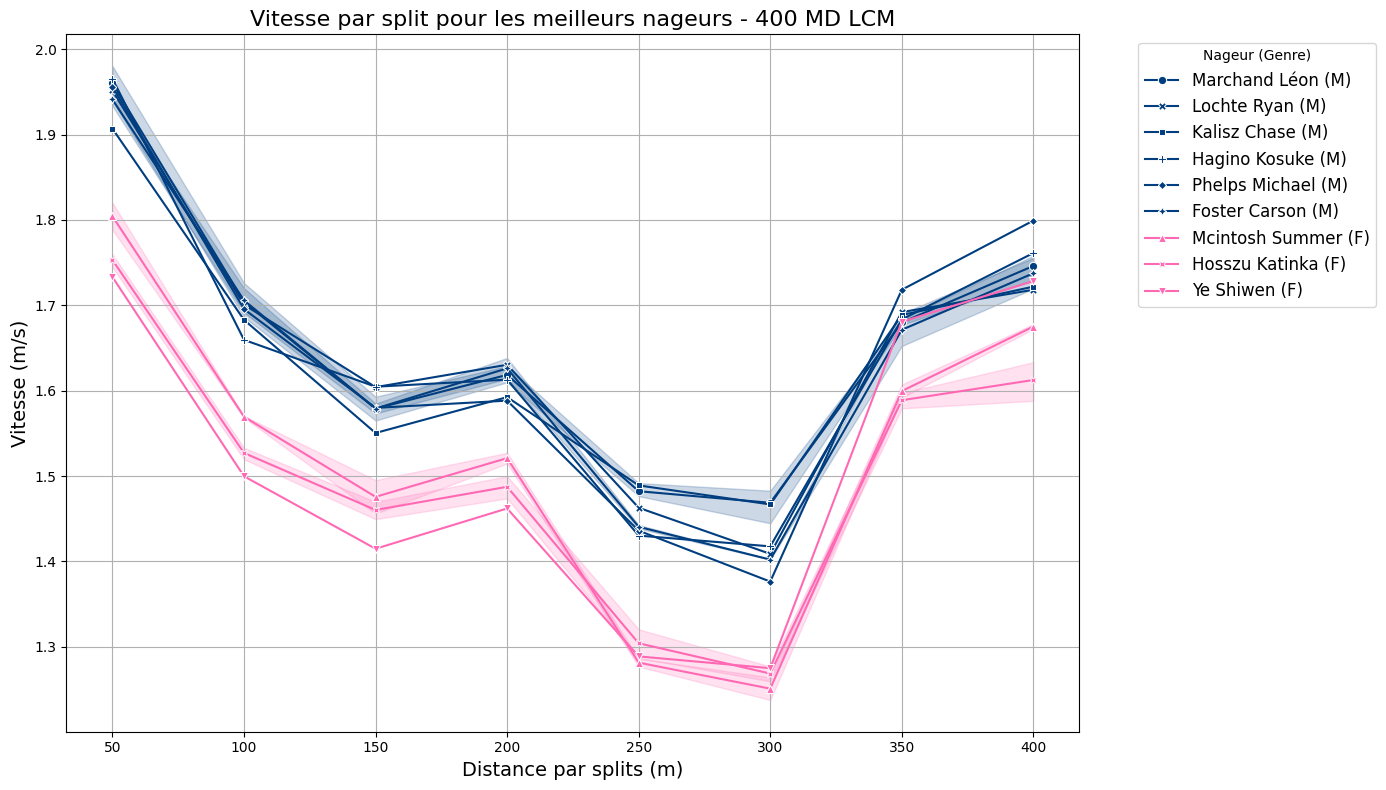

In [50]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmer in a given event</h1>

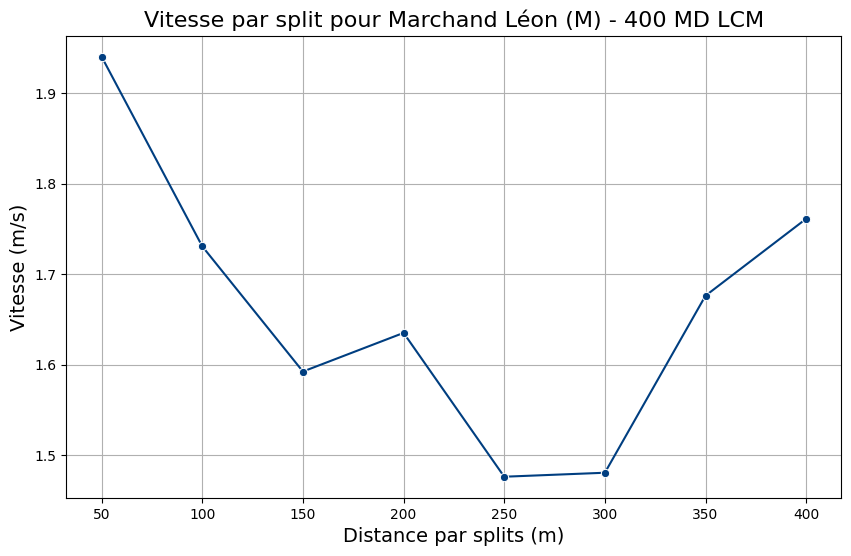

In [46]:
nom_event = "400 MD LCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]

best_name = df_best['swimmer_name']
best_gender = df_best['swimmer_gender']
best_splits = df_best['splits']

split_data = []
for s in best_splits:
    if s['split_speed'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_data.append({
            'split_distance': dist,
            'split_speed': s['split_speed']
        })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print(f"Aucun split valide trouvé pour le meilleur nageur de l'Event {nom_event}.")
else:
    plt.figure(figsize=(10,6))
    color = "#003E80" if best_gender == 'M' else "#FF69B4"

    sns.lineplot(
        x='split_distance',
        y='split_speed',
        data=df_splits,
        marker='o',
        color=color
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of average of swim time by splits</h1>

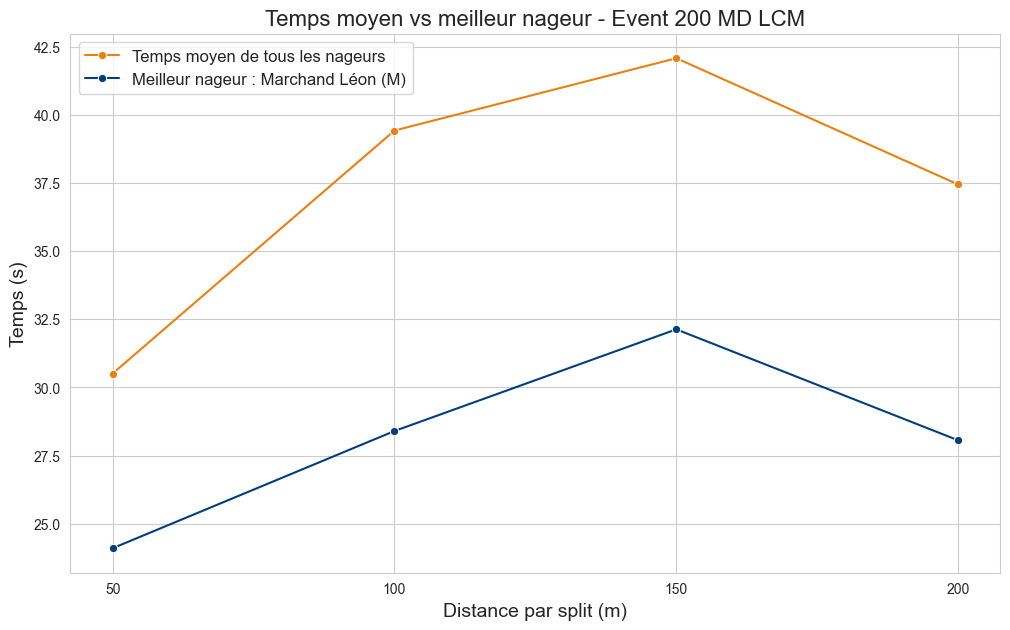

In [34]:
nom_event = "200 MD LCM"  
df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(), df_best_splits['split_distance'].max())+50, 50))
plt.title(f"Temps moyen vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

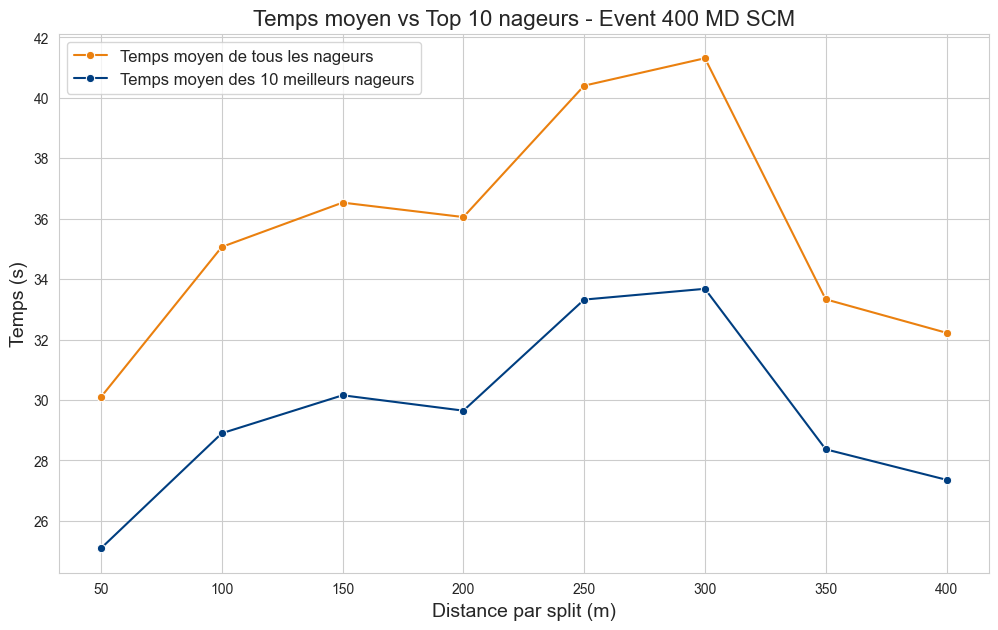

In [35]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_mean = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_mean,
    marker='o',
    color="#003E80",
    label="Temps moyen des 10 meilleurs nageurs"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(),
                         df_top10_mean['split_distance'].max()) + 50, 50))

plt.title(f"Temps moyen vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

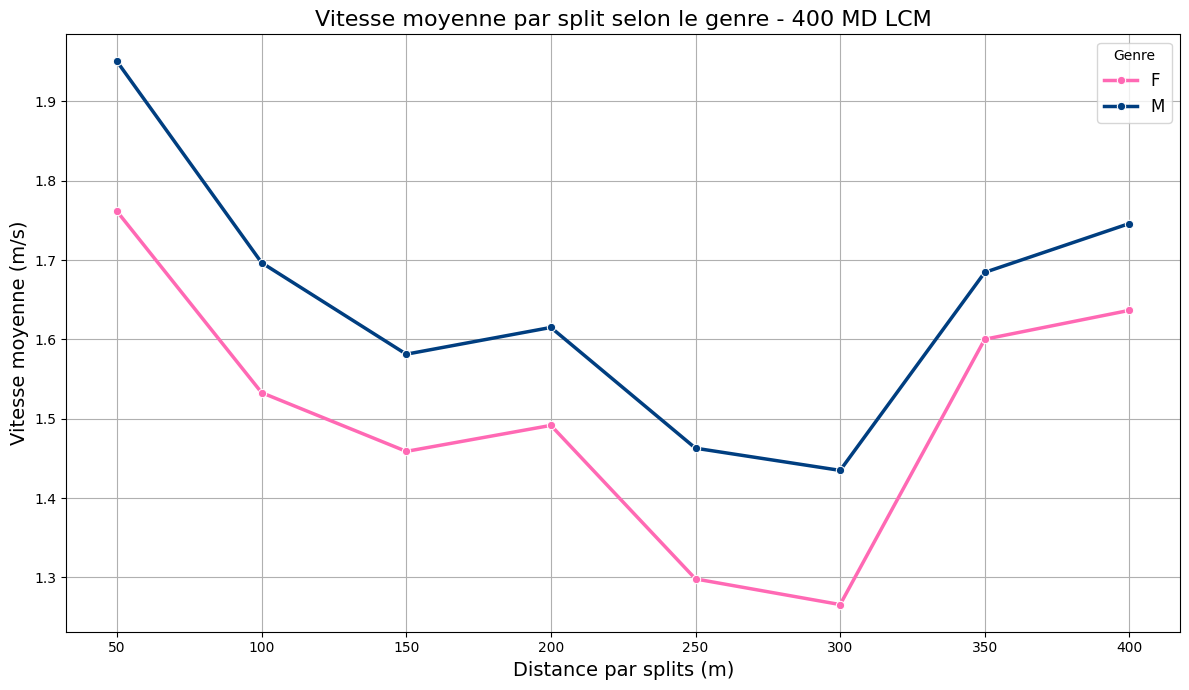

In [ ]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            dist = int(s['split_distance'].replace(' m',''))
            split_speed = s['split_speed'] if s['split_speed'] is not None else float('nan')
            split_data.append({
                'gender': gender,
                'split_distance': dist,
                'split_speed': split_speed
            })

df_splits = pd.DataFrame(split_data)

df_avg = df_splits.groupby(['gender', 'split_distance'])['split_speed'].mean().reset_index()

plt.figure(figsize=(12,7))
palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

sns.lineplot(
    x='split_distance',
    y='split_speed',
    hue='gender',
    data=df_avg,
    marker='o',
    palette=palette_colors,
    linewidth=2.5
)

plt.xticks(range(50, int(df_splits['split_distance'].max())+50, 50))
plt.title(f"Vitesse moyenne par split selon le genre - {nom_event}", fontsize=16)
plt.xlabel("Distance par splits (m)", fontsize=14)
plt.ylabel("Vitesse moyenne (m/s)", fontsize=14)
plt.grid(True)
plt.legend(title='Genre', fontsize=12)
plt.tight_layout()
plt.show()


Contrôle des distances observées par split_no :


,split_no,split_distance,n_rows
0,1,50,20129
1,2,100,20129
2,3,150,20129
3,4,200,20129
4,5,250,20129
5,6,300,20129
6,7,350,20129
7,8,400,20129


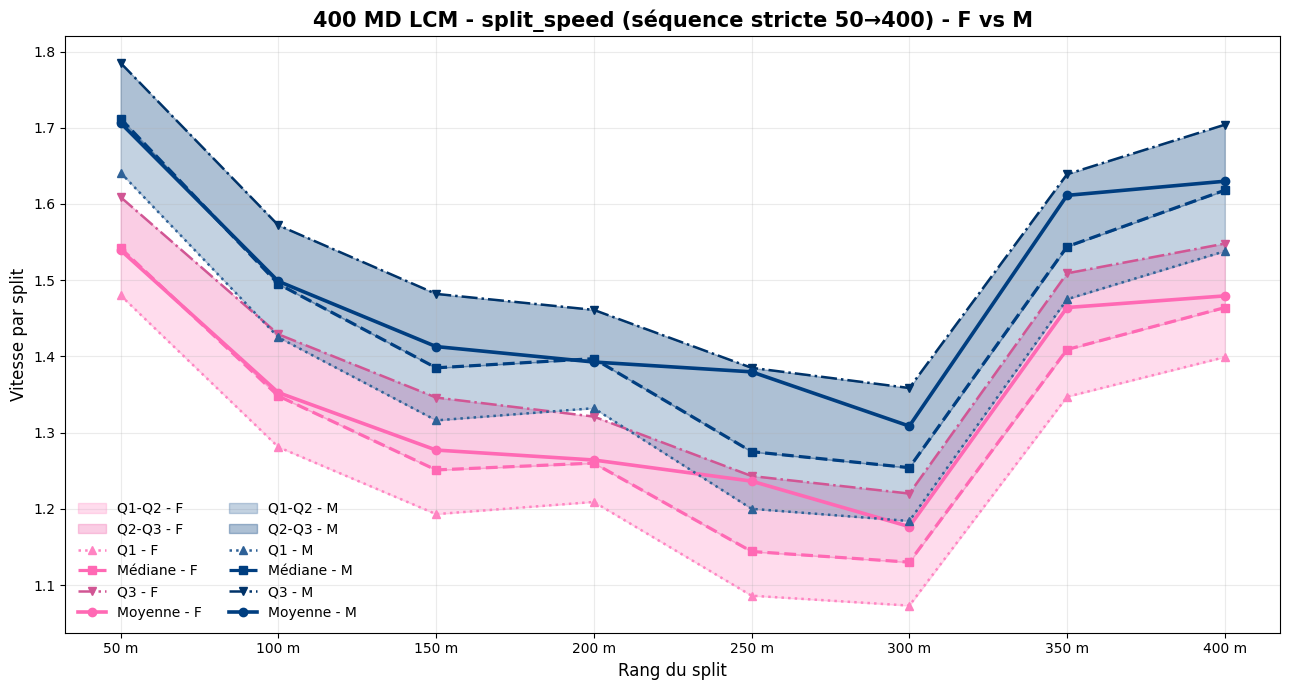

,Gender,split_no,split_distance_theorique,mean,median,q1,q3,n
0,F,1,50,1.5394,1.542,1.480,1.6090,9438
1,F,2,100,1.3524,1.348,1.281,1.4290,9438
2,F,3,150,1.2771,1.251,1.193,1.3460,9438
3,F,4,200,1.2640,1.260,1.209,1.3210,9438
4,F,5,250,1.2363,1.144,1.086,1.2430,9438
5,F,6,300,1.1766,1.130,1.073,1.2200,9438
6,F,7,350,1.4641,1.409,1.347,1.5090,9438
7,F,8,400,1.4794,1.464,1.399,1.5480,9438
8,M,1,50,1.7063,1.712,1.641,1.7850,10691
9,M,2,100,1.4985,1.495,1.425,1.5720,10691



Nombre de performances retenues (séquence stricte) : 20129
Nombre total de valeurs split_speed utilisées : 161032


In [ ]:
import matplotlib.colors as mcolors

nom_event = "400 MD LCM"
palette = {"F": "#FF69B4", "M": "#003E80"}

# Séquence stricte attendue des splits
expected = ["50 m", "100 m", "150 m", "200 m", "250 m", "300 m", "350 m", "400 m"]

def adjust_color(color, factor=1.0):
    r, g, b = mcolors.to_rgb(color)
    if factor >= 1:
        r = r + (1 - r) * (factor - 1)
        g = g + (1 - g) * (factor - 1)
        b = b + (1 - b) * (factor - 1)
    else:
        r *= factor
        g *= factor
        b *= factor
    return (min(max(r, 0), 1), min(max(g, 0), 1), min(max(b, 0), 1))

def parse_dist(x):
    try:
        return int(str(x).replace(" m", "").strip())
    except Exception:
        return None

def has_expected_prefix(splits, expected_list):
    """
    Garde seulement les perfs qui ont au moins les 8 premiers splits:
    50,100,150,200,250,300,350,400
    et split_speed non null pour ces positions.
    """
    if not isinstance(splits, list) or len(splits) < len(expected_list):
        return False
    for i, exp in enumerate(expected_list):
        si = splits[i]
        if not isinstance(si, dict):
            return False
        if str(si.get("split_distance")).strip() != exp:
            return False
        if si.get("split_speed") is None:
            return False
    return True

df_event = df[
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: has_expected_prefix(s, expected))
].copy()

split_rows = []
for _, row in df_event.iterrows():
    swimmers = row.get("swimmer", [])
    splits = row.get("splits", [])

    if not (isinstance(swimmers, list) and len(swimmers) > 0):
        continue

    gender = swimmers[0].get("Gender")
    if gender not in ["F", "M"]:
        continue

    # on prend uniquement les 8 premiers splits (50 -> 400)
    for i, s in enumerate(splits[:len(expected)]):
        if not isinstance(s, dict):
            continue

        dist = parse_dist(s.get("split_distance"))
        speed = s.get("split_speed")
        if dist is None or speed is None:
            continue

        try:
            speed = float(speed)
        except (ValueError, TypeError):
            continue

        split_rows.append({
            "Gender": gender,
            "split_no": i + 1,       # 1..8
            "split_distance": dist,  # 50..400
            "split_speed": speed
        })

df_splits = pd.DataFrame(split_rows)

if df_splits.empty:
    print("Aucune donnée exploitable après filtre strict.")
else:
    check = (
        df_splits.groupby(["split_no", "split_distance"])
        .size()
        .reset_index(name="n_rows")
        .sort_values(["split_no", "split_distance"])
    )
    print("Contrôle des distances observées par split_no :")
    display(check)

    stats = (
        df_splits
        .groupby(["Gender", "split_no"])["split_speed"]
        .agg(
            mean="mean",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n="count"
        )
        .reset_index()
        .sort_values(["Gender", "split_no"])
        .reset_index(drop=True)
    )

    stats["split_distance_theorique"] = stats["split_no"] * 50

    plt.figure(figsize=(13, 7))

    for g in ["F", "M"]:
        d = stats[stats["Gender"] == g].sort_values("split_no")
        if d.empty:
            continue

        base_color = palette[g]
        zone_q1_q2 = adjust_color(base_color, 1.28)  
        zone_q2_q3 = adjust_color(base_color, 0.95)  
        plt.fill_between(
            d["split_no"], d["q1"], d["median"],
            color=zone_q1_q2, alpha=0.32, label=f"Q1-Q2 - {g}"
        )
        plt.fill_between(
            d["split_no"], d["median"], d["q3"],
            color=zone_q2_q3, alpha=0.32, label=f"Q2-Q3 - {g}"
        )

        plt.plot(
            d["split_no"], d["q1"],
            color=adjust_color(base_color, 1.18),
            linewidth=1.8, linestyle=":", marker="^", label=f"Q1 - {g}"
        )
        plt.plot(
            d["split_no"], d["median"],
            color=base_color,
            linewidth=2.3, linestyle="--", marker="s", label=f"Médiane - {g}"
        )
        plt.plot(
            d["split_no"], d["q3"],
            color=adjust_color(base_color, 0.82),
            linewidth=1.8, linestyle="-.", marker="v", label=f"Q3 - {g}"
        )
        plt.plot(
            d["split_no"], d["mean"],
            color=base_color,
            linewidth=2.6, linestyle="-", marker="o", label=f"Moyenne - {g}"
        )

    ticks = list(range(1, len(expected) + 1))
    plt.xticks(ticks, expected)

    plt.title(f"{nom_event} - split_speed (séquence stricte 50→400) - F vs M", fontsize=15, weight="bold")
    plt.xlabel("Rang du split", fontsize=12)
    plt.ylabel("Vitesse par split", fontsize=12)
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    stats_display = stats.copy()
    for col in ["mean", "median", "q1", "q3"]:
        stats_display[col] = stats_display[col].round(4)

    display(stats_display[[
        "Gender", "split_no", "split_distance_theorique", "mean", "median", "q1", "q3", "n"
    ]])

    print("\nNombre de performances retenues (séquence stricte) :", len(df_event))
    print("Nombre total de valeurs split_speed utilisées :", len(df_splits))

In [92]:
nom_event = "400 MD LCM"
gender_target = "F"

mask_base = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == "50 m"
        )
    )
)

df_base = df.loc[mask_base].copy()
nb_base = len(df_base)

mask_second_split_valid = df_base["splits"].apply(
    lambda s: (
        isinstance(s, list)
        and len(s) > 1
        and isinstance(s[1], dict)
        and str(s[1].get("split_distance")).strip() == "100 m"
        and pd.notna(s[1].get("split_speed"))
    )
)

nb_second_split_100_speed_notnull = mask_second_split_valid.sum()

print(f"Base pour {gender_target} (1er split = 50 m) : {nb_base}")
print(
    f"Nombre de perfs avec 2e split = 100 m et split_speed non null : "
    f"{nb_second_split_100_speed_notnull}"
)

if nb_base > 0:
    pct = nb_second_split_100_speed_notnull / nb_base * 100
    print(f"Pourcentage dans la base : {pct:.2f}%")

Base pour F (1er split = 50 m) : 9744
Nombre de perfs avec 2e split = 100 m et split_speed non null : 9740
Pourcentage dans la base : 99.96%


In [ ]:
nom_event = "400 MD LCM"
gender_target = "M"

mask = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
    & df["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip() == "100 m"
        if isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
        else False
    )
)

nb_perf_valides = mask.sum()

print(
    f"Nombre de performances valides avec premier split = 100 m pour l'event {nom_event} "
    f"et Gender {gender_target} : {nb_perf_valides}"
)

Nombre de performances valides avec premier split = 100 m pour l'event 400 MD LCM et Gender M : 10896


In [83]:
gender_target = "M"

base_mask = (
    (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
    )
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance valide dans la base.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Gender : {gender_target}")
    print(f"Total performances valides (base) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Gender : M
Total performances valides (base) : 264675
Premier split = 100 m : 10896 (4.12%)
Premier split = 50 m  : 253184 (95.66%)


In [58]:
nom_event = "400 MD LCM"
first_split_target = "400 m"   

mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == first_split_target
        )
    )
)

# Meets concernés (uniques)
meets_first_split = (
    df.loc[mask, "Meet"]
      .dropna()
      .astype(str)
      .str.strip()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)

print(f"Nombre de meets où le 1er split = {first_split_target} pour {nom_event} : {len(meets_first_split)}")
display(meets_first_split.to_frame(name="Meet"))

df_examples = df.loc[mask, ["Meet", "SwimDate", "Event", "SwimTime", "SwimTimeSeconds", "swimmer", "splits"]].copy()

df_examples["Name"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)
df_examples["Gender"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)

n_examples = 5

print(f"\nExemple(s) de performances (top {n_examples}) :")
display(
    df_examples[["Meet", "SwimDate", "Name", "Gender", "Event", "SwimTime", "SwimTimeSeconds"]]
    .head(n_examples)
)

if len(df_examples) > 0:
    print("\nSplits détaillés du 1er exemple :")
    display(pd.DataFrame(df_examples.iloc[0]["splits"]))
else:
    print("\nAucune performance trouvée pour ce filtre.")

Nombre de meets où le 1er split = 400 m pour 400 MD LCM : 1


,Meet
0,Jeux Olympiques



Exemple(s) de performances (top 5) :


,Meet,SwimDate,Name,Gender,Event,SwimTime,SwimTimeSeconds
30812,Jeux Olympiques,1992-07-31,Bonnet Céline,F,400 MD LCM,04:54.70,294.7



Splits détaillés du 1er exemple :


,split_distance,split_time,split_seconds,split_speed,cumul_seconds,split_time_cumul
0,400 m,04:54.70,294.7,0.17,294.7,4:54.70


In [60]:
nom_event = "400 MD LCM" 

base_mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict))
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance avec splits dans la base filtrée.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Event considéré : {nom_event}")
    print(f"Total performances (avec au moins 1 split) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Event considéré : 400 MD LCM
Total performances (avec au moins 1 split) : 24127
Premier split = 100 m : 3328 (13.79%)
Premier split = 50 m  : 20794 (86.19%)


In [ ]:
base_mask = df["splits"].apply(
    lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
)
df_base = df.loc[base_mask, ["Event", "splits"]].copy()

if df_base.empty:
    print("Aucune performance avec splits.")
else:
    # Premier split_distance
    df_base["first_split_distance"] = df_base["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip()
    )

    # Totaux par event
    total_by_event = (
        df_base.groupby("Event", dropna=False)
               .size()
               .rename("total_perf")
               .reset_index()
    )

    count_100 = (
        df_base[df_base["first_split_distance"] == "100 m"]
        .groupby("Event", dropna=False)
        .size()
        .rename("n_first_split_100m")
        .reset_index()
    )

    count_50 = (
        df_base[df_base["first_split_distance"] == "50 m"]
        .groupby("Event", dropna=False)
        .size()
        .rename("n_first_split_50m")
        .reset_index()
    )

    # Fusion
    table = (
        total_by_event
        .merge(count_100, on="Event", how="left")
        .merge(count_50, on="Event", how="left")
        .fillna(0)
    )

    # Types int
    table["n_first_split_100m"] = table["n_first_split_100m"].astype(int)
    table["n_first_split_50m"] = table["n_first_split_50m"].astype(int)

    # Pourcentages
    table["pct_first_split_100m"] = (table["n_first_split_100m"] / table["total_perf"] * 100).round(2)
    table["pct_first_split_50m"] = (table["n_first_split_50m"] / table["total_perf"] * 100).round(2)

    # Tri (optionnel)
    table = table.sort_values("total_perf", ascending=False).reset_index(drop=True)

    display(table)

,Event,total_perf,n_first_split_100m,n_first_split_50m,pct_first_split_100m,pct_first_split_50m
0,100 FR LCM,43567,5,43562,0.01,99.99
1,200 FR LCM,36310,1945,34365,5.36,94.64
2,400 FR LCM,33882,3282,30597,9.69,90.30
3,100 FL LCM,32731,2,32729,0.01,99.99
4,200 MD LCM,31987,1854,30131,5.80,94.20
5,100 BR LCM,30609,20,30589,0.07,99.93
6,100 BK LCM,30145,4,30141,0.01,99.99
7,200 BR LCM,25254,1112,24140,4.40,95.59
8,200 BK LCM,24327,908,23419,3.73,96.27
9,400 MD LCM,24127,3328,20794,13.79,86.19


# Vérification des valeurs

In [ ]:
nom_event = "400 MD LCM"
gender_target = "F"

df_event = df[
    (df["Event"] == nom_event)
    & (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target))
].copy()

split_rows = []
for _, row in df_event.iterrows():
    splits = row.get("splits", [])
    if isinstance(splits, list):
        for s in splits:
            split_distance = s.get("split_distance")
            split_speed = s.get("split_speed")

            if split_distance is None or split_speed is None:
                continue

            try:
                dist = int(str(split_distance).replace(" m", "").strip())   
                speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_rows.append({
                "split_distance": dist,
                "split_speed": speed
            })

df_splits = pd.DataFrame(split_rows)

if df_splits.empty:
    print("Aucune donnée de split_speed trouvée pour 400 MD LCM / Gender M.")
else:
    stats_splits = (
        df_splits
        .groupby("split_distance", as_index=False)
        .agg(
            moyenne_split_speed=("split_speed", "mean"),
            mediane_split_speed=("split_speed", "median"),
            n=("split_speed", "count")
        )
        .sort_values("split_distance")
    )

    stats_splits["moyenne_split_speed"] = stats_splits["moyenne_split_speed"].round(4)
    stats_splits["mediane_split_speed"] = stats_splits["mediane_split_speed"].round(4)

    display(stats_splits)

,split_distance,moyenne_split_speed,mediane_split_speed,n
0,50,1.5375,1.540,9744
1,100,1.2592,1.326,11343
2,150,1.2759,1.251,9516
3,200,1.1606,1.241,11332
4,250,1.2353,1.143,9533
5,300,1.0910,1.109,11333
6,350,1.4636,1.409,9511
7,400,1.3595,1.440,11349


In [47]:
print("Les event disponibles sont :")
print(df["Event"].unique()) 
print("Le nombre de event disponibles :",len(df["Event"].unique())) 

Les event disponibles sont :
['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']
Le nombre de event disponibles : 44


In [49]:
df_filtered = df[
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)) &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1))
]

events_filtered = df_filtered['Event'].unique()

print("Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est :", len(events_filtered))

Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est : 26


In [41]:
nom_event = "50 FL LCM"

df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

df_filtered = df[df['swimmer_name'].notna()]

total_participations = (
    df_filtered[df_filtered['Event'] == nom_event]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='total_participations')
)

valid_performances = (
    df_filtered[(df_filtered['Event'] == nom_event) & df_filtered['SwimTimeSeconds'].notna()]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='valid_performances')
)

top_swimmers = pd.merge(total_participations, valid_performances, on='swimmer_name', how='left')

top_swimmers = top_swimmers.sort_values(by='total_participations', ascending=False).head(10)

top_swimmers['valid_performances'] = top_swimmers['valid_performances'].fillna(0).astype(int)
top_swimmers['total_participations'] = top_swimmers['total_participations'].astype(int)

top_swimmers = top_swimmers.rename(columns={
    'swimmer_name': 'Nom des nageurs',
    'total_participations': 'Total performances',
    'valid_performances': 'Total performances valides'
})

print("Les nageurs qui ont le nombre de performances le plus élevé pour le event", nom_event, " :")
print(top_swimmers)

Les nageurs qui ont le nombre de performances le plus élevé pour le event 50 FL LCM  :
          Nom des nageurs  Total performances  Total performances valides
5719      Henique Mélanie                 144                         143
12866        Wattel Marie                  82                          81
1652   Bousquet Frédérick                  76                          76
5333      Grousset Maxime                  72                          71
8481        Metella Mehdy                  69                          68
9917         Piron Thomas                  62                          62
434        Arlandis Anais                  61                          61
9569    Pedro-Leal Dorian                  60                          60
7957     Manaudou Florent                  60                          59
1862        Bruno Justine                  58                          58


In [42]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur ayant le nombre de performances le plus élevé est :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur ayant le nombre de performances le plus élevé est :
           swimmer_name      Event  count
129264  Henique Mélanie  50 FL LCM    144


In [43]:
df_solo = df[df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1)]

df_solo['swimmer_name'] = df_solo['swimmer'].apply(lambda x: x[0]['Name'])

participations = df_solo.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur avec le plus de performances individuelles :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur avec le plus de performances individuelles :
           swimmer_name      Event  count
118709  Henique Mélanie  50 FL LCM    144


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_38361/4013526156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solo['swimmer_name'] = df_solo['swimmer'].apply(lambda x: x[0]['Name'])


In [21]:
df_exploded = df.explode('swimmer')

def extract_field(x, field):
    return x.get(field) if isinstance(x, dict) else None

df_exploded['Name'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Name'))
df_exploded['Year_of_birth'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Year_of_birth'))
df_exploded['Age'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Age'))
df_exploded['Gender'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Gender'))

df_exploded['SwimYear'] = pd.to_datetime(df_exploded['SwimDate']).dt.year

year_counts = (
    df_exploded
    .groupby('Name')['Year_of_birth']
    .nunique()
    .reset_index(name='nb_years')
)

multiple_years = year_counts[year_counts['nb_years'] > 1]['Name'].tolist()

print(f"Nombre de nageurs avec plusieurs Year_of_birth : {len(multiple_years)}")

pourcentage_nageurs = (
    len(multiple_years) / df_exploded['Name'].nunique()
) * 100

print(f"Pourcentage de nageurs concernés : {pourcentage_nageurs:.2f}%\n")


df_problematic = df_exploded[
    df_exploded['Name'].isin(multiple_years)
]


age_check = (
    df_problematic
    .groupby(['Name', 'SwimYear', 'Year_of_birth'])['Age']
    .nunique()
    .reset_index(name='nb_ages')
)

age_inconsistencies = age_check[age_check['nb_ages'] > 1]

print("Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :")
print(age_inconsistencies)


nb_nageurs_problematiques = df_problematic['Name'].nunique()

pourcentage_incoherences = (
    len(age_inconsistencies) / nb_nageurs_problematiques
) * 100 if nb_nageurs_problematiques > 0 else 0

print(f"\nPourcentage de nageurs avec incohérences d'Age : {pourcentage_incoherences:.2f}%")


gender_check = (
    df_exploded
    .groupby('Name')
    .agg({
        'Year_of_birth': 'nunique',
        'Gender': 'nunique'
    })
    .reset_index()
)

same_gender_multiple_yob = gender_check[
    (gender_check['Year_of_birth'] > 1) &
    (gender_check['Gender'] == 1)
]

print(f"\nNombre de nageurs avec plusieurs Year_of_birth et même Gender : {len(same_gender_multiple_yob)}")

Nombre de nageurs avec plusieurs Year_of_birth : 312
Pourcentage de nageurs concernés : 0.46%

Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :
                  Name  SwimYear  Year_of_birth  nb_ages
15        Angot Julien      2009           1992        2
16        Angot Julien      2010           1992        2
52     Bernard Camille      2017           2002        2
54     Bernard Camille      2019           2002        2
86     Boudet Clémence      2011           1995        2
...                ...       ...            ...      ...
1163     Seebohm Emily      2016           1992        2
1192      Smith Daniel      2016           1991        2
1215    Thomas Mathieu      2005           1984        2
1253  Wagner Alexandre      2005           1988        2
1275            Yu Rui      2004           1982        2

[144 rows x 4 columns]

Pourcentage de nageurs avec incohérences d'Age : 46.15%

Nombre de nageurs avec plusieurs Year_of_birth et même Gender : 306


In [19]:
nom_nageur = "Angot Julien"
annee = 2005

df_nageur = df_exploded[
    (df_exploded['Name'] == nom_nageur) &
    (df_exploded['Year_of_birth'] == annee)
]

print("Nombre de performances du nageur :", len(df_nageur))

meet_nageur = df_nageur['Meet'].unique()

events_nageur = df_nageur['Event'].unique()

print(f"\n Meets pour {nom_nageur} ({annee}) :")
print(meet_nageur)

print(f"\n Events pour {nom_nageur} ({annee}) :")
print(events_nageur)

Nombre de performances du nageur : 2

 Meets pour Angot Julien (2005) :
['Interclubs Départementaux Toutes Catégories-LOIRE-ATLANTIQUE']

 Events pour Angot Julien (2005) :
['100 FL SCM' '500 FR SCM']


In [ ]:
swimmer_name_target = "Angot Julien"
swimmer_name_clean = swimmer_name_target.strip().lower()

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0]["Name"].strip().lower() if isinstance(x, list) and len(x) > 0 else None
)

df_swimmer = df[df["swimmer_name"] == swimmer_name_clean].copy()

distinct_years = df_swimmer["swimmer"].apply(
    lambda x: x[0].get("Year_of_birth") if isinstance(x, list) and len(x) > 0 else None
).dropna().unique()

print(f"Années de naissance distinctes pour {swimmer_name_target} :")
print(distinct_years)

Années de naissance distinctes pour Angot Julien :
[1992 2005]
[19 16 20 18 14 17 13 15]


In [24]:
total_lignes = len(df)

nb_null = df['SwimTimeSeconds'].isna().sum()
pourcentage_null = (nb_null / total_lignes) * 100

nb_empty = (df['SwimTimeSeconds'] == "").sum()
pourcentage_empty = (nb_empty / total_lignes) * 100

print(f"Nombre de SwimTimeSeconds nulles (NaN) : {nb_null} ({pourcentage_null:.2f}%)")
print(f"Nombre de SwimTimeSeconds vides ('') : {nb_empty} ({pourcentage_empty:.2f}%)")

Nombre de SwimTimeSeconds nulles (NaN) : 10596 (1.39%)
Nombre de SwimTimeSeconds vides ('') : 0 (0.00%)


<h1 style="color:#F0B4B4; font-size:32px;">Couloirs de performance (nageur + événement)</h1>


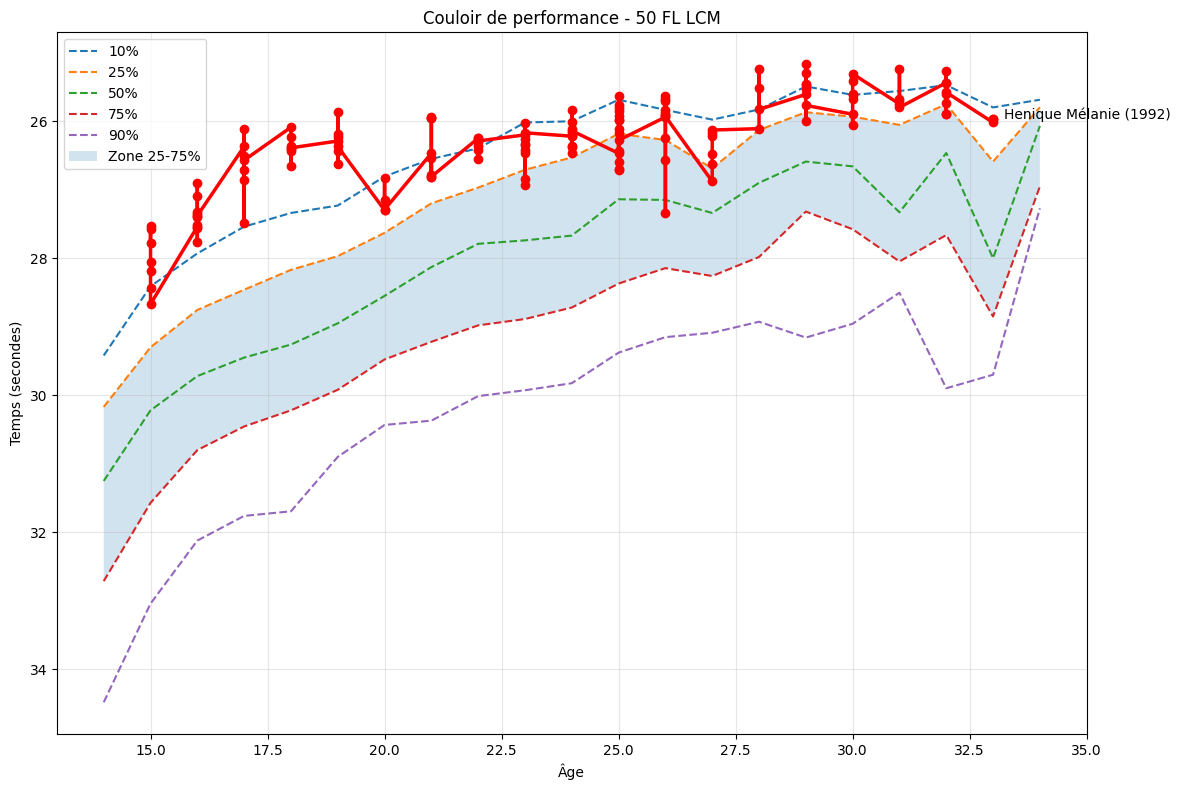

In [12]:
def build_long_swims(df, solo_only=True):
    data = df.copy()

    if solo_only:
        data = data[data["swimmer"].apply(
            lambda x: isinstance(x, list) and len(x) == 1
        )]

    data["swimmer_dict"] = data["swimmer"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) == 1 else None
    )

    data["Name"] = data["swimmer_dict"].apply(lambda x: x.get("Name") if isinstance(x, dict) else None)
    data["Gender"] = data["swimmer_dict"].apply(lambda x: x.get("Gender") if isinstance(x, dict) else None)
    data["Year_of_birth"] = data["swimmer_dict"].apply(lambda x: x.get("Year_of_birth") if isinstance(x, dict) else None)
    data["Age_json"] = data["swimmer_dict"].apply(lambda x: x.get("Age") if isinstance(x, dict) else None)

    data["SwimYear"] = pd.to_datetime(data["SwimDate"], errors="coerce").dt.year

    data["Age_swim"] = data["Age_json"]

    mask = (
        data["Age_swim"].isna() &
        data["Year_of_birth"].notna() &
        data["SwimYear"].notna()
    )

    data.loc[mask, "Age_swim"] = (
        data.loc[mask, "SwimYear"] - data.loc[mask, "Year_of_birth"]
    )

    data["Age_swim"] = pd.to_numeric(data["Age_swim"], errors="coerce").astype("Int64")

    return data

def performance_corridor_plot_time(
    df,
    nom_event,
    nom_nageur,
    year_of_birth,
    age_min=14,
    age_max=35,
    solo_only=True,
    min_points=5,
    figsize=(12, 8),
):

    long_df = build_long_swims(df, solo_only=solo_only)

    long_df = long_df[
        (long_df["Event"] == nom_event) &
        (long_df["SwimTimeSeconds"].notna()) &
        (long_df["Name"].notna()) &
        (long_df["Gender"].notna()) &
        (long_df["Age_swim"].notna()) &
        (long_df["Year_of_birth"].notna())
    ].copy()

    if long_df.empty:
        print(f"Aucune donnée pour {nom_event}")
        return

    target_name = nom_nageur.strip().lower()

    swimmer_data = long_df[
        (long_df["Name"].str.strip().str.lower() == target_name) &
        (long_df["Year_of_birth"] == year_of_birth)
    ]

    if swimmer_data.empty:
        print(f"Nageur introuvable : {nom_nageur} ({year_of_birth})")
        print("Exemples :", long_df["Name"].drop_duplicates().head(10).tolist())
        return

    gender = swimmer_data["Gender"].mode().iloc[0]
    long_df = long_df[long_df["Gender"] == gender]

    swimmer_name = swimmer_data.iloc[0]["Name"]
    swimmer_yob = swimmer_data.iloc[0]["Year_of_birth"]

    percentiles = [10, 25, 50, 75, 90]

    grouped = long_df.groupby("Age_swim")["SwimTimeSeconds"].agg(list)

    grouped = grouped.apply(
        lambda x: x if len(x) >= min_points else np.nan
    ).dropna()

    df_percentiles = pd.DataFrame({
        f"p{p}": grouped.apply(lambda x: np.percentile(x, p))
        for p in percentiles
    })

    df_percentiles = df_percentiles.loc[
        (df_percentiles.index >= age_min) &
        (df_percentiles.index <= age_max)
    ]

    df_swimmer = long_df[
        (long_df["Name"] == swimmer_name) &
        (long_df["Year_of_birth"] == swimmer_yob)
    ].sort_values("Age_swim")

    fig, ax = plt.subplots(figsize=figsize)

    for p in percentiles:
        ax.plot(
            df_percentiles.index,
            df_percentiles[f"p{p}"],
            linestyle="--",
            label=f"{p}%"
        )

    ax.fill_between(
        df_percentiles.index,
        df_percentiles["p25"],
        df_percentiles["p75"],
        alpha=0.2,
        label="Zone 25-75%"
    )

    ax.plot(
        df_swimmer["Age_swim"],
        df_swimmer["SwimTimeSeconds"],
        color="red",
        linewidth=2.5,
        marker="o"
    )

    if not df_swimmer.empty:
        last = df_swimmer.iloc[-1]
        ax.scatter(last["Age_swim"], last["SwimTimeSeconds"], color="red")
        ax.annotate(
            f"{swimmer_name} ({swimmer_yob})",
            (last["Age_swim"], last["SwimTimeSeconds"]),
            xytext=(8, 0),
            textcoords="offset points"
        )

    ax.invert_yaxis()
    ax.set_xlabel("Âge")
    ax.set_ylabel("Temps (secondes)")
    ax.set_title(f"Couloir de performance - {nom_event}")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    return fig, ax

performance_corridor_plot_time(
    df,
    nom_event="50 FL LCM",
    nom_nageur="Henique Mélanie",
    year_of_birth=1992
)

plt.show()